# Data Preparation & Exploratory Analysis

This notebook covers:
1. **Column renaming** — human-readable names for all 40 features
2. **Missingness assessment** — visualize what is still missing after the gap filter
3. **Imputation** — strategy varies by column type (monthly time-series vs. annual contextual vs. national rates)
4. **Correlation analysis** — level correlations and first-differenced correlations to separate genuine redundancy from spurious time-trend correlation
5. **Feature recommendations** — which columns to consider dropping before modeling

Input: `data/processed/consolidated_zip_month_redfin_gap_filtered_model_cols.csv`  
Output: `data/processed/modeling_ready.csv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

INPUT_PATH  = '../data/processed/consolidated_zip_month_redfin_gap_filtered_model_cols.csv'
OUTPUT_PATH = '../data/processed/modeling_ready.csv'

---
## 1. Load Data

In [2]:
df = pd.read_csv(INPUT_PATH)

# drop the data-quality diagnostic column — not a real feature
df = df.drop(columns=['redfin_coverage'], errors='ignore')

# normalize zip and month
df['zip']   = df['zip'].astype(str).str.zfill(5)
df['month'] = pd.to_datetime(df['month'])
df = df.sort_values(['zip', 'month']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'ZIPs: {df["zip"].nunique()}')
print(f'Date range: {df["month"].min().date()} → {df["month"].max().date()}')
df.head(3)

Shape: (55944, 40)
ZIPs: 666
Date range: 2018-01-31 → 2024-12-31


,zip,month,year,zhvi,MEDIAN_SALE_PRICE,MEDIAN_LIST_PRICE,MEDIAN_PPSF,MEDIAN_LIST_PPSF,HOMES_SOLD,PENDING_SALES,NEW_LISTINGS,INVENTORY,MEDIAN_DOM,AVG_SALE_TO_LIST,SOLD_ABOVE_LIST,OFF_MARKET_IN_TWO_WEEKS,pmms30,pmms15,pmms51,pmms51spread,B19013_001E,B25077_001E,B25064_001E,owner_rate,ESTAB,EMP,PAYANN,PAYQTR1,avg_annual_pay_per_emp,N1,A00100,A00200,A00300,A00600,zhvi_mom_pct,zhvi_yoy_pct,MEDIAN_SALE_PRICE_mom_pct,MEDIAN_SALE_PRICE_yoy_pct,INVENTORY_mom_pct,INVENTORY_yoy_pct
0,27006,2018-01-31,2018,245572.7754,220000.0000,275007.5000,102.9748,112.4457,47.0000,75.0000,96.0000,140.0000,130.0000,0.9384,0.1064,0.3200,4.0325,3.4825,3.4725,0.5600,78095.0000,228900.0000,870.0000,0.8748,302.0000,2975.0000,104263.0000,23662.0000,35.0464,6980.0000,682650.0000,419556.0000,5998.0000,24663.0000,0.0050,0.0383,-0.1235,-0.1431,0.1765,0.2389
1,27006,2018-02-28,2018,246589.4087,258500.0000,275007.5000,99.6526,112.2291,64.0000,93.0000,122.0000,143.0000,135.0000,0.9550,0.1250,0.4516,4.3300,3.7850,3.5950,0.7350,78095.0000,228900.0000,870.0000,0.8748,302.0000,2975.0000,104263.0000,23662.0000,35.0464,6980.0000,682650.0000,419556.0000,5998.0000,24663.0000,0.0041,0.0388,0.1750,0.1071,0.0214,0.2768
2,27006,2018-03-31,2018,247588.1938,261000.0000,280000.0000,105.9256,111.8926,88.0000,101.0000,123.0000,130.0000,115.5000,0.9691,0.1818,0.4455,4.4440,3.9100,3.6520,0.7920,78095.0000,228900.0000,870.0000,0.8748,302.0000,2975.0000,104263.0000,23662.0000,35.0464,6980.0000,682650.0000,419556.0000,5998.0000,24663.0000,0.0041,0.0391,0.0097,0.2111,-0.0909,0.0000


---
## 2. Column Renaming

Groups:
- **Keys:** zip, month, year (`year` is derived from `month` — do not use as a model feature)
- **Zillow:** home value index + MoM/YoY  
- **Redfin:** monthly market activity + MoM/YoY  
- **Mortgage rates (PMMS):** national macro context — same value for every ZIP in the same month  
- **ACS:** annual demographic context (income, rent, owner occupancy)  
- **CBP:** annual business/employment structure  
- **IRS SOI:** annual income and tax-return indicators

In [3]:
RENAME = {
    'zip'                       : 'zip',
    'month'                     : 'month',
    'year'                      : 'year',
    'zhvi'                      : 'home_value_index',
    'zhvi_mom_pct'              : 'home_value_mom_pct',
    'zhvi_yoy_pct'              : 'home_value_yoy_pct',
    'MEDIAN_SALE_PRICE'         : 'median_sale_price',
    'MEDIAN_LIST_PRICE'         : 'median_list_price',
    'MEDIAN_PPSF'               : 'median_price_per_sqft',
    'MEDIAN_LIST_PPSF'          : 'median_list_price_per_sqft',
    'HOMES_SOLD'                : 'homes_sold',
    'PENDING_SALES'             : 'pending_sales',
    'NEW_LISTINGS'              : 'new_listings',
    'INVENTORY'                 : 'inventory',
    'MEDIAN_DOM'                : 'median_days_on_market',
    'AVG_SALE_TO_LIST'          : 'avg_sale_to_list_ratio',
    'SOLD_ABOVE_LIST'           : 'pct_sold_above_list',
    'OFF_MARKET_IN_TWO_WEEKS'   : 'pct_off_market_in_2wks',
    'MEDIAN_SALE_PRICE_mom_pct' : 'sale_price_mom_pct',
    'MEDIAN_SALE_PRICE_yoy_pct' : 'sale_price_yoy_pct',
    'INVENTORY_mom_pct'         : 'inventory_mom_pct',
    'INVENTORY_yoy_pct'         : 'inventory_yoy_pct',
    'pmms30'                    : 'mortgage_rate_30yr',
    'pmms15'                    : 'mortgage_rate_15yr',
    'pmms51'                    : 'mortgage_rate_5_1_arm',
    'pmms51spread'              : 'mortgage_arm_spread',
    'B19013_001E'               : 'median_household_income',
    'B25077_001E'               : 'median_owner_home_value',
    'B25064_001E'               : 'median_gross_rent',
    'owner_rate'                : 'owner_occupancy_rate',
    'ESTAB'                     : 'business_establishments',
    'EMP'                       : 'total_employment',
    'PAYANN'                    : 'annual_payroll',
    'PAYQTR1'                   : 'q1_payroll',
    'avg_annual_pay_per_emp'    : 'avg_pay_per_employee',
    'N1'                        : 'tax_returns_filed',
    'A00100'                    : 'adjusted_gross_income',
    'A00200'                    : 'wages_and_salaries',
    'A00300'                    : 'taxable_interest_income',
    'A00600'                    : 'ordinary_dividends',
}

df = df.rename(columns=RENAME)
print('Columns after rename:')
print(list(df.columns))

Columns after rename:
['zip', 'month', 'year', 'home_value_index', 'median_sale_price', 'median_list_price', 'median_price_per_sqft', 'median_list_price_per_sqft', 'homes_sold', 'pending_sales', 'new_listings', 'inventory', 'median_days_on_market', 'avg_sale_to_list_ratio', 'pct_sold_above_list', 'pct_off_market_in_2wks', 'mortgage_rate_30yr', 'mortgage_rate_15yr', 'mortgage_rate_5_1_arm', 'mortgage_arm_spread', 'median_household_income', 'median_owner_home_value', 'median_gross_rent', 'owner_occupancy_rate', 'business_establishments', 'total_employment', 'annual_payroll', 'q1_payroll', 'avg_pay_per_employee', 'tax_returns_filed', 'adjusted_gross_income', 'wages_and_salaries', 'taxable_interest_income', 'ordinary_dividends', 'home_value_mom_pct', 'home_value_yoy_pct', 'sale_price_mom_pct', 'sale_price_yoy_pct', 'inventory_mom_pct', 'inventory_yoy_pct']


---
## 3. Missingness Assessment

The gap filter already removed ZIPs with **3+ consecutive missing months** in any model column.  
Remaining gaps should be at most 2 months long — but let's confirm and visualize.

In [4]:
FEATURE_COLS = [c for c in df.columns if c not in ('zip', 'month', 'year')]

miss = pd.DataFrame({
    'missing_count' : df[FEATURE_COLS].isna().sum(),
    'missing_pct'   : (df[FEATURE_COLS].isna().mean() * 100).round(2),
}).sort_values('missing_pct', ascending=False)

print(f'Total rows: {len(df):,}')
print(f'Columns with any missing: {(miss["missing_pct"] > 0).sum()} / {len(FEATURE_COLS)}')
print()
miss[miss['missing_pct'] > 0]

Total rows: 55,944
Columns with any missing: 34 / 37



,missing_count,missing_pct
median_gross_rent,17064,30.5000
mortgage_arm_spread,16650,29.7600
mortgage_rate_5_1_arm,16650,29.7600
ordinary_dividends,16404,29.3200
taxable_interest_income,16404,29.3200
wages_and_salaries,16404,29.3200
tax_returns_filed,16404,29.3200
adjusted_gross_income,16404,29.3200
median_household_income,16080,28.7400
median_owner_home_value,16044,28.6800


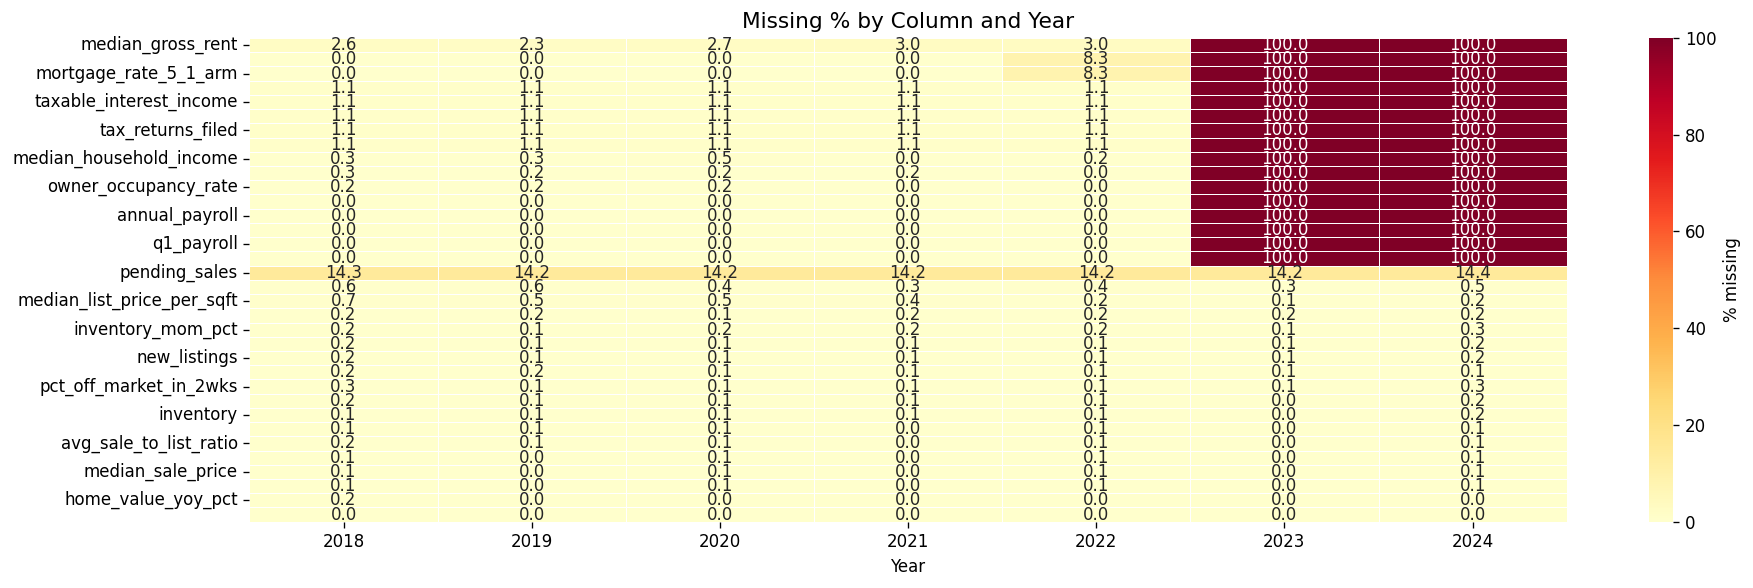

In [5]:
# --- Missingness heatmap: column vs year ---
# _year computed inline — df is never mutated here
cols_with_missing = miss[miss['missing_pct'] > 0].index.tolist()

miss_by_year = (
    df.assign(_year=df['month'].dt.year)
    .groupby('_year')[cols_with_missing]
    .apply(lambda g: g.isna().mean() * 100)
    .round(1)
)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    miss_by_year.T,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': '% missing'}
)
ax.set_title('Missing % by Column and Year', fontsize=13)
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

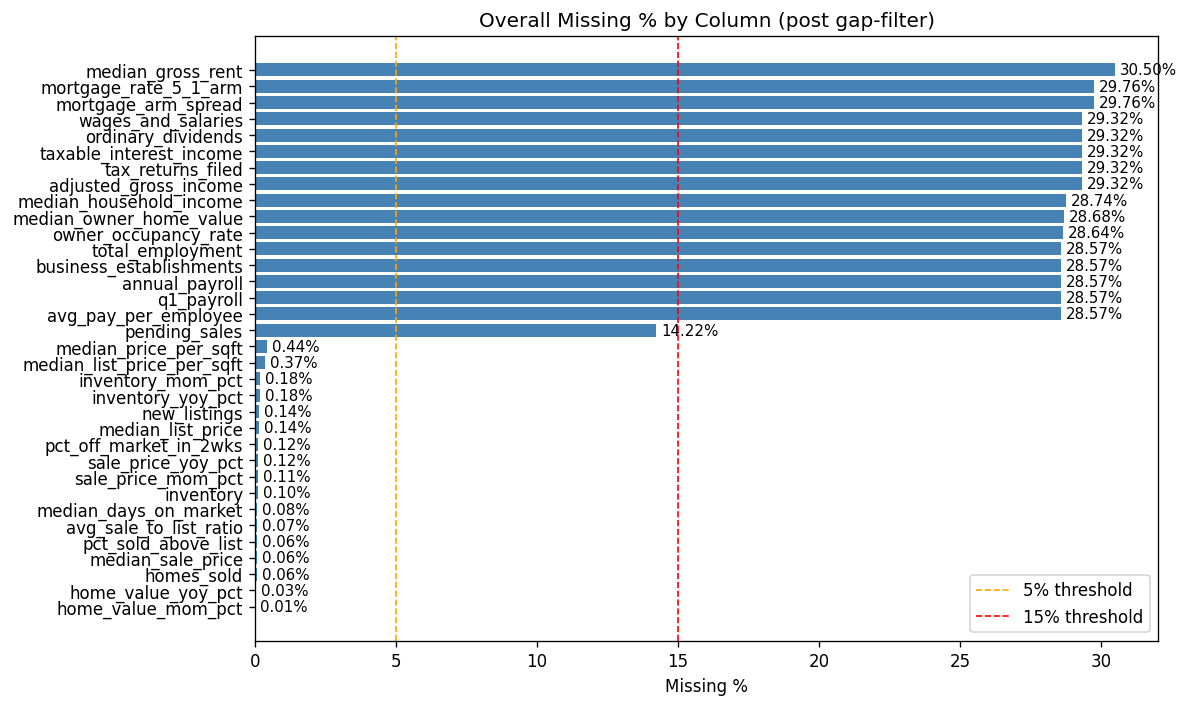

In [6]:
# --- Bar chart: overall missing % per column ---
miss_nonzero = miss[miss['missing_pct'] > 0].sort_values('missing_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(miss_nonzero.index, miss_nonzero['missing_pct'], color='steelblue')
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=9)
ax.set_xlabel('Missing %')
ax.set_title('Overall Missing % by Column (post gap-filter)')
ax.axvline(5, color='orange', linestyle='--', linewidth=1, label='5% threshold')
ax.axvline(15, color='red', linestyle='--', linewidth=1, label='15% threshold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Imputation

Three strategies based on column type:

| Group | Columns | Strategy |
|---|---|---|
| **A — Monthly time-series** | Zillow + Redfin levels + MoM/YoY | Linear interpolation within ZIP → ffill/bfill for edges |
| **B — Annual contextual** | ACS + CBP + IRS | Forward-fill then backward-fill within ZIP (step-function nature of annual data) |
| **C — National rates** | Mortgage rates (PMMS) | Linear interpolation globally (same value across all ZIPs) |

**Why MoM/YoY columns belong in Group A (not re-derived):**  
The original MoM/YoY columns were computed from the full raw dataset going back to 2000, so January 2018's values correctly use December 2017 (MoM) and January 2017 (YoY) context. If we re-derive within the 2018–2022 window, that prior-year context is gone — every ZIP would lose its entire first year of YoY values (6,480 NaNs per column instead of ~50). The original values are correct; we just need to fill the small gaps.

In [7]:
GROUP_A = [
    'home_value_index', 'home_value_mom_pct', 'home_value_yoy_pct',
    'median_sale_price', 'median_list_price',
    'median_price_per_sqft', 'median_list_price_per_sqft',
    'sale_price_mom_pct', 'sale_price_yoy_pct',
    'homes_sold', 'pending_sales', 'new_listings', 'inventory', 'median_days_on_market',
    'inventory_mom_pct', 'inventory_yoy_pct',
    'avg_sale_to_list_ratio', 'pct_sold_above_list', 'pct_off_market_in_2wks',
]

GROUP_B = [
    'median_household_income', 'median_owner_home_value', 'median_gross_rent', 'owner_occupancy_rate',
    'business_establishments', 'total_employment', 'annual_payroll', 'q1_payroll', 'avg_pay_per_employee',
    'tax_returns_filed', 'adjusted_gross_income', 'wages_and_salaries',
    'taxable_interest_income', 'ordinary_dividends',
]

GROUP_C = [
    'mortgage_rate_30yr', 'mortgage_rate_15yr', 'mortgage_rate_5_1_arm', 'mortgage_arm_spread',
]

print('Group A (monthly, linear interp):  ', len(GROUP_A), 'columns')
print('Group B (annual, ffill+bfill):     ', len(GROUP_B), 'columns')
print('Group C (national rates, interp):  ', len(GROUP_C), 'columns')
print('Total feature columns:             ', len(GROUP_A) + len(GROUP_B) + len(GROUP_C))

Group A (monthly, linear interp):   19 columns
Group B (annual, ffill+bfill):      14 columns
Group C (national rates, interp):   4 columns
Total feature columns:              37


In [8]:
df = df.sort_values(['zip', 'month']).reset_index(drop=True)

df[GROUP_A] = (
    df.groupby('zip')[GROUP_A]
    .transform(lambda s: s.interpolate(method='linear').ffill().bfill())
)
print(f'Group A — remaining nulls: {df[GROUP_A].isna().sum().sum()}')

Group A — remaining nulls: 7896


In [9]:
df[GROUP_B] = (
    df.groupby('zip')[GROUP_B]
    .transform(lambda s: s.ffill().bfill())
)
print(f'Group B — remaining nulls: {df[GROUP_B].isna().sum().sum()}')

Group B — remaining nulls: 3360


In [10]:
# All four rate columns had exactly 1 national month missing (540 rows = 1 month × 540 ZIPs).
df[GROUP_C] = df[GROUP_C].interpolate(method='linear').ffill().bfill()
print(f'Group C — remaining nulls: {df[GROUP_C].isna().sum().sum()}')

Group C — remaining nulls: 0


In [11]:
all_feature_cols = GROUP_A + GROUP_B + GROUP_C
post_miss = df[all_feature_cols].isna().sum()
post_miss = post_miss[post_miss > 0]

if len(post_miss) == 0:
    print('All feature columns fully imputed — no missing values remain.')
else:
    print('Remaining missing values:')
    print(post_miss)

print(f'\nShape: {df.shape}')

Remaining missing values:
pending_sales              7896
median_gross_rent           420
tax_returns_filed           588
adjusted_gross_income       588
wages_and_salaries          588
taxable_interest_income     588
ordinary_dividends          588
dtype: int64

Shape: (55944, 40)


---
## 5. Correlation Analysis

We run correlation analysis **twice** and compare:

- **Level correlation** — standard Pearson on raw values. Fast to compute and useful for spotting near-duplicate columns, but can be inflated by shared time trends (spurious correlation).
- **First-differenced correlation** — Pearson on month-over-month changes within each ZIP. Removes ZIP fixed effects and shared time trends. Shows whether two columns genuinely co-move period-to-period, independent of common drift.

Annual columns (ACS, CBP, IRS) are excluded from the differenced analysis — their values only change once a year, so first differences are mostly zero and the correlations are not meaningful.

> **Rule of thumb:** a pair that stays highly correlated after differencing is genuinely redundant. A pair whose correlation drops significantly after differencing was mostly sharing a common time trend, not actual co-movement.

### 5a. Level Correlation

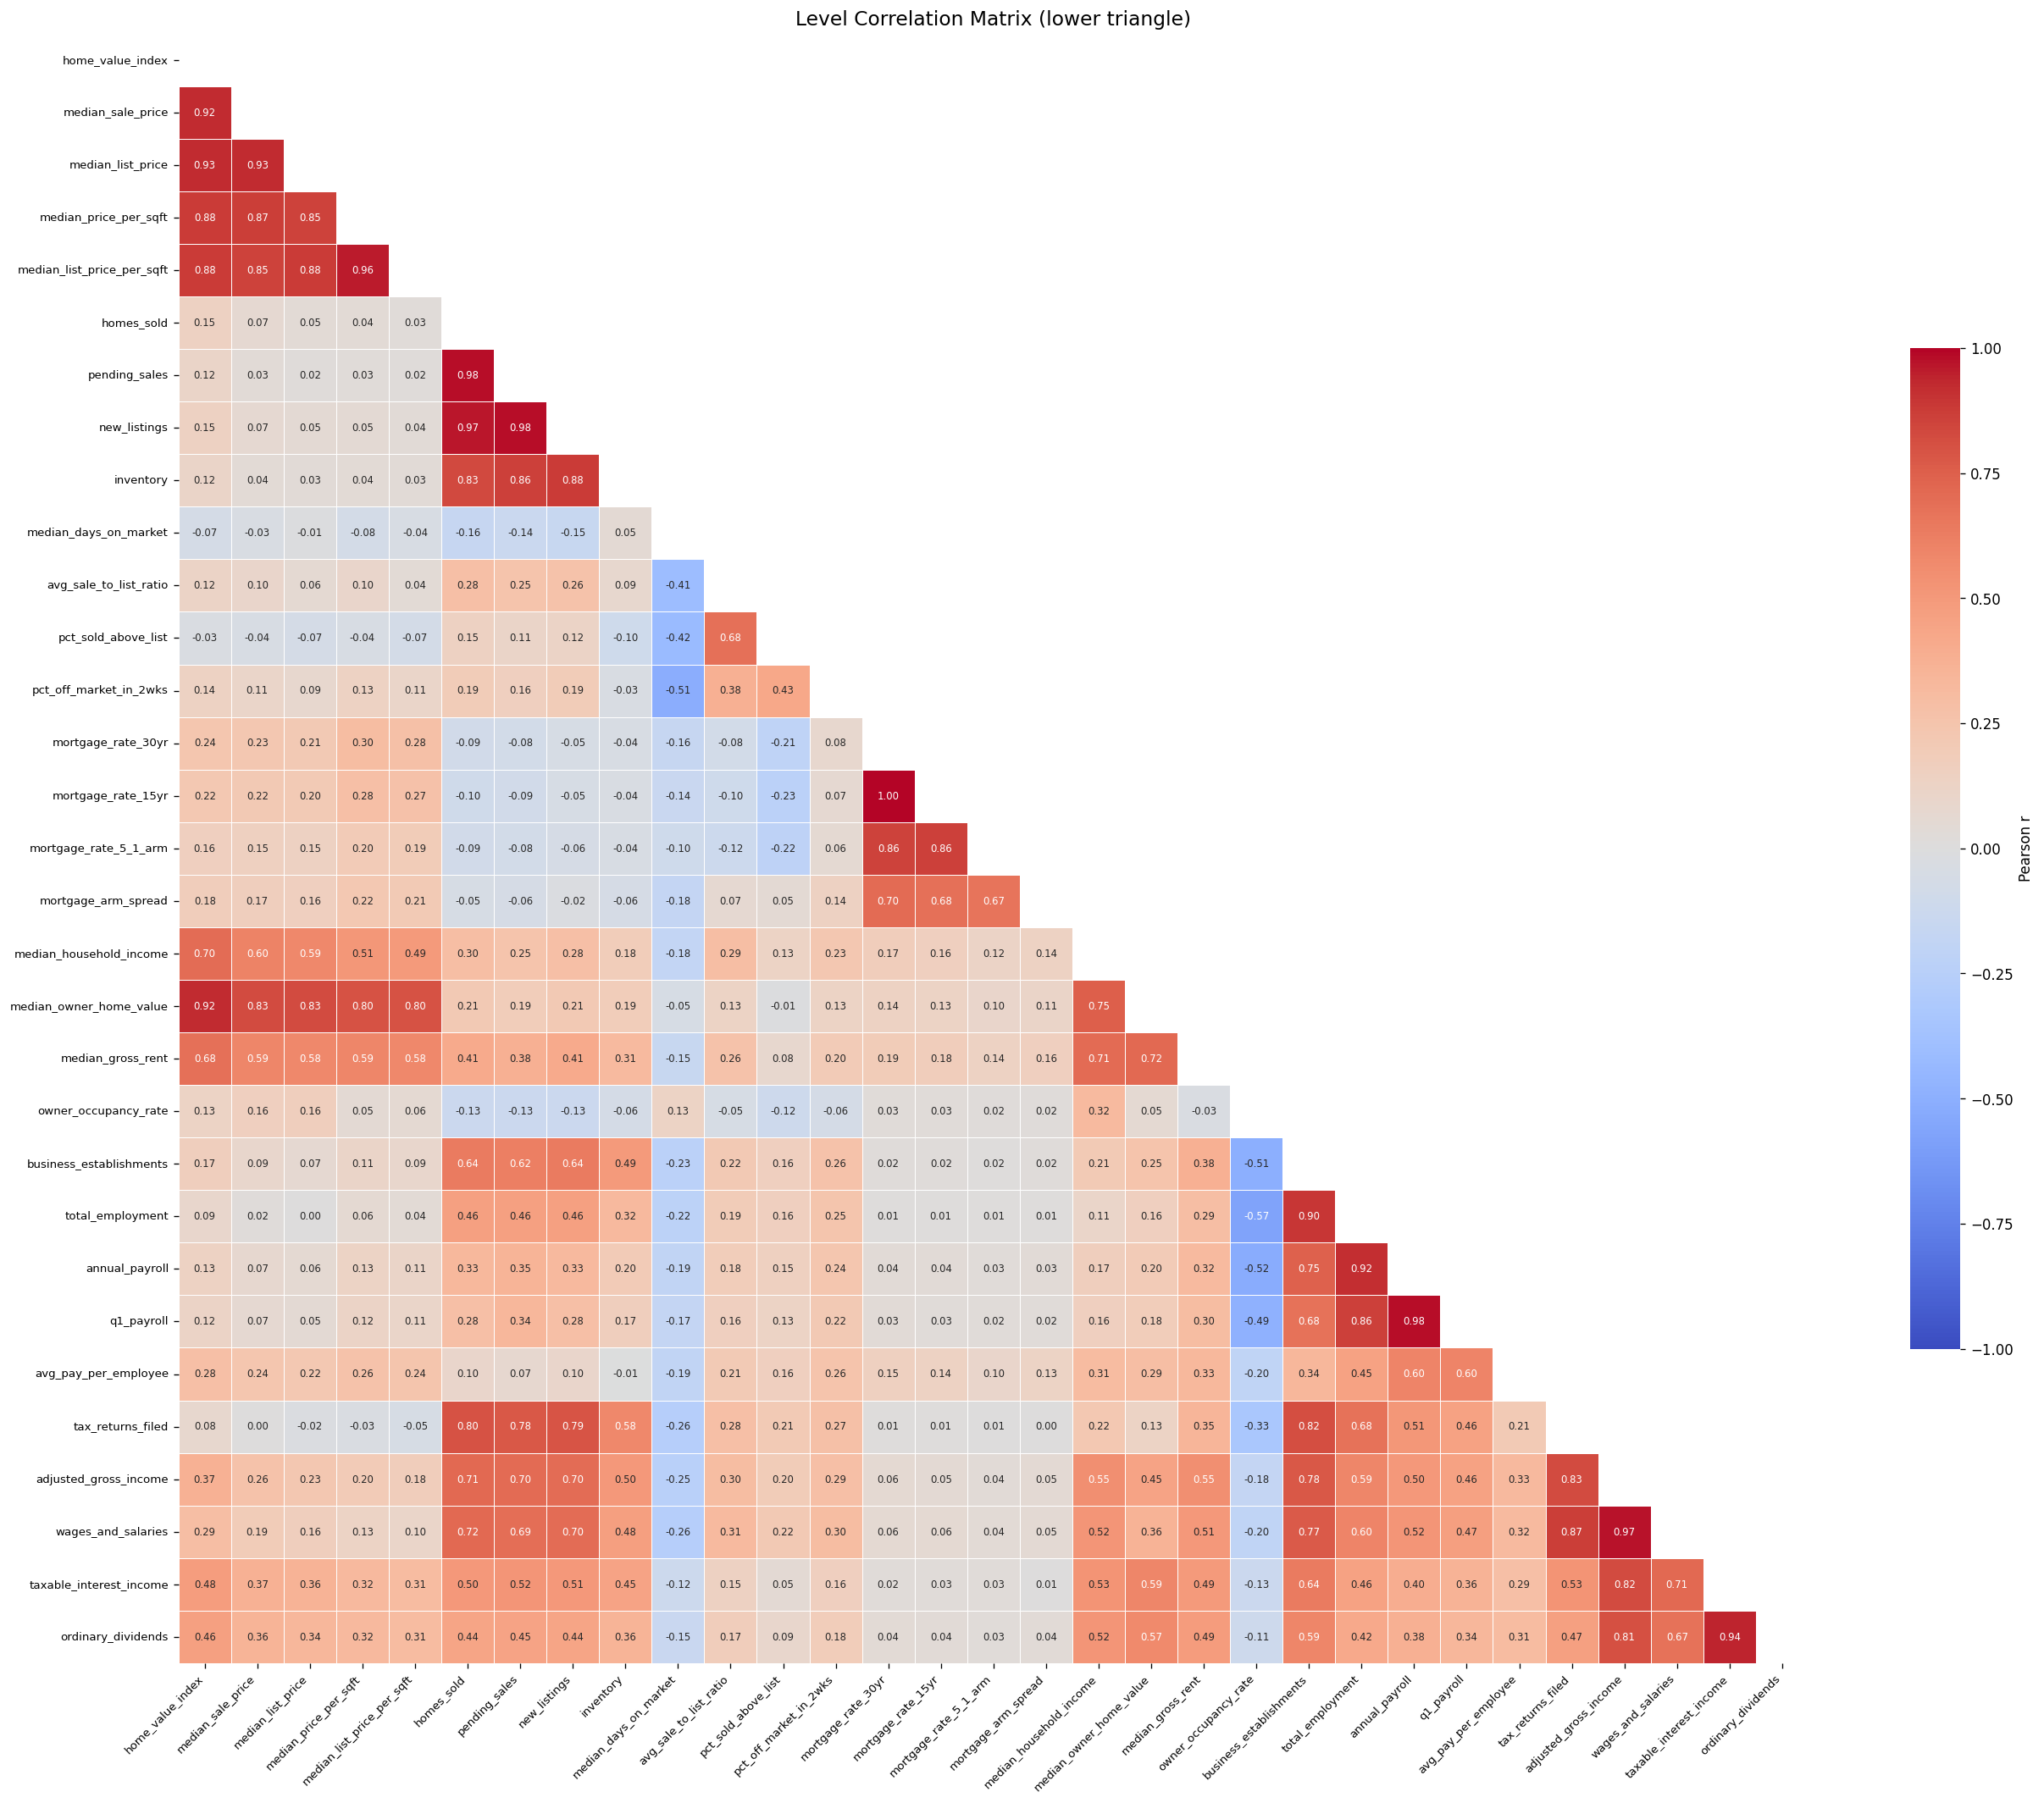

In [12]:
LEVEL_COLS = [
    'home_value_index',
    'median_sale_price', 'median_list_price', 'median_price_per_sqft', 'median_list_price_per_sqft',
    'homes_sold', 'pending_sales', 'new_listings', 'inventory', 'median_days_on_market',
    'avg_sale_to_list_ratio', 'pct_sold_above_list', 'pct_off_market_in_2wks',
    'mortgage_rate_30yr', 'mortgage_rate_15yr', 'mortgage_rate_5_1_arm', 'mortgage_arm_spread',
    'median_household_income', 'median_owner_home_value', 'median_gross_rent', 'owner_occupancy_rate',
    'business_establishments', 'total_employment', 'annual_payroll', 'q1_payroll', 'avg_pay_per_employee',
    'tax_returns_filed', 'adjusted_gross_income', 'wages_and_salaries',
    'taxable_interest_income', 'ordinary_dividends',
]

corr_level = df[LEVEL_COLS].corr()

fig, ax = plt.subplots(figsize=(22, 18))
mask = np.triu(np.ones_like(corr_level, dtype=bool))
sns.heatmap(
    corr_level, mask=mask,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.3, square=True, ax=ax,
    cbar_kws={'shrink': 0.6, 'label': 'Pearson r'}
)
ax.set_title('Level Correlation Matrix (lower triangle)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [13]:
# --- High-correlation pairs from level correlation (|r| >= 0.85) ---
THRESHOLD = 0.85

def get_pairs(corr_matrix, label):
    pairs = (
        corr_matrix
        .where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
        .stack()
        .reset_index()
    )
    pairs.columns = ['feature_1', 'feature_2', label]
    return pairs

level_pairs = get_pairs(corr_level, 'r_level')
high_corr_level = (
    level_pairs[level_pairs['r_level'].abs() >= THRESHOLD]
    .sort_values('r_level', ascending=False)
    .reset_index(drop=True)
)

print(f'Pairs with |level r| >= {THRESHOLD}: {len(high_corr_level)}')
high_corr_level

Pairs with |level r| >= 0.85: 26


,feature_1,feature_2,r_level
0,mortgage_rate_15yr,mortgage_rate_30yr,0.9979
1,q1_payroll,annual_payroll,0.9841
2,pending_sales,homes_sold,0.9840
3,new_listings,pending_sales,0.9767
4,wages_and_salaries,adjusted_gross_income,0.9742
5,new_listings,homes_sold,0.9679
6,median_list_price_per_sqft,median_price_per_sqft,0.9588
7,ordinary_dividends,taxable_interest_income,0.9429
8,median_list_price,home_value_index,0.9262
9,median_list_price,median_sale_price,0.9256


### 5b. First-Differenced Correlation

First differences are computed **within each ZIP** (month-over-month change). This removes:
- The ZIP's own level (fixed effect) — a consistently expensive ZIP won't inflate correlations with other expensive ZIPs
- Shared time trends — if home values and incomes both drifted upward 2018–2022, that drift no longer drives the correlation

What remains is: do these two variables move together in the **same months** in the **same ZIPs**?

Annual columns (ACS/CBP/IRS) are excluded — their monthly first differences are zero 11 out of 12 months, making the correlation uninformative.

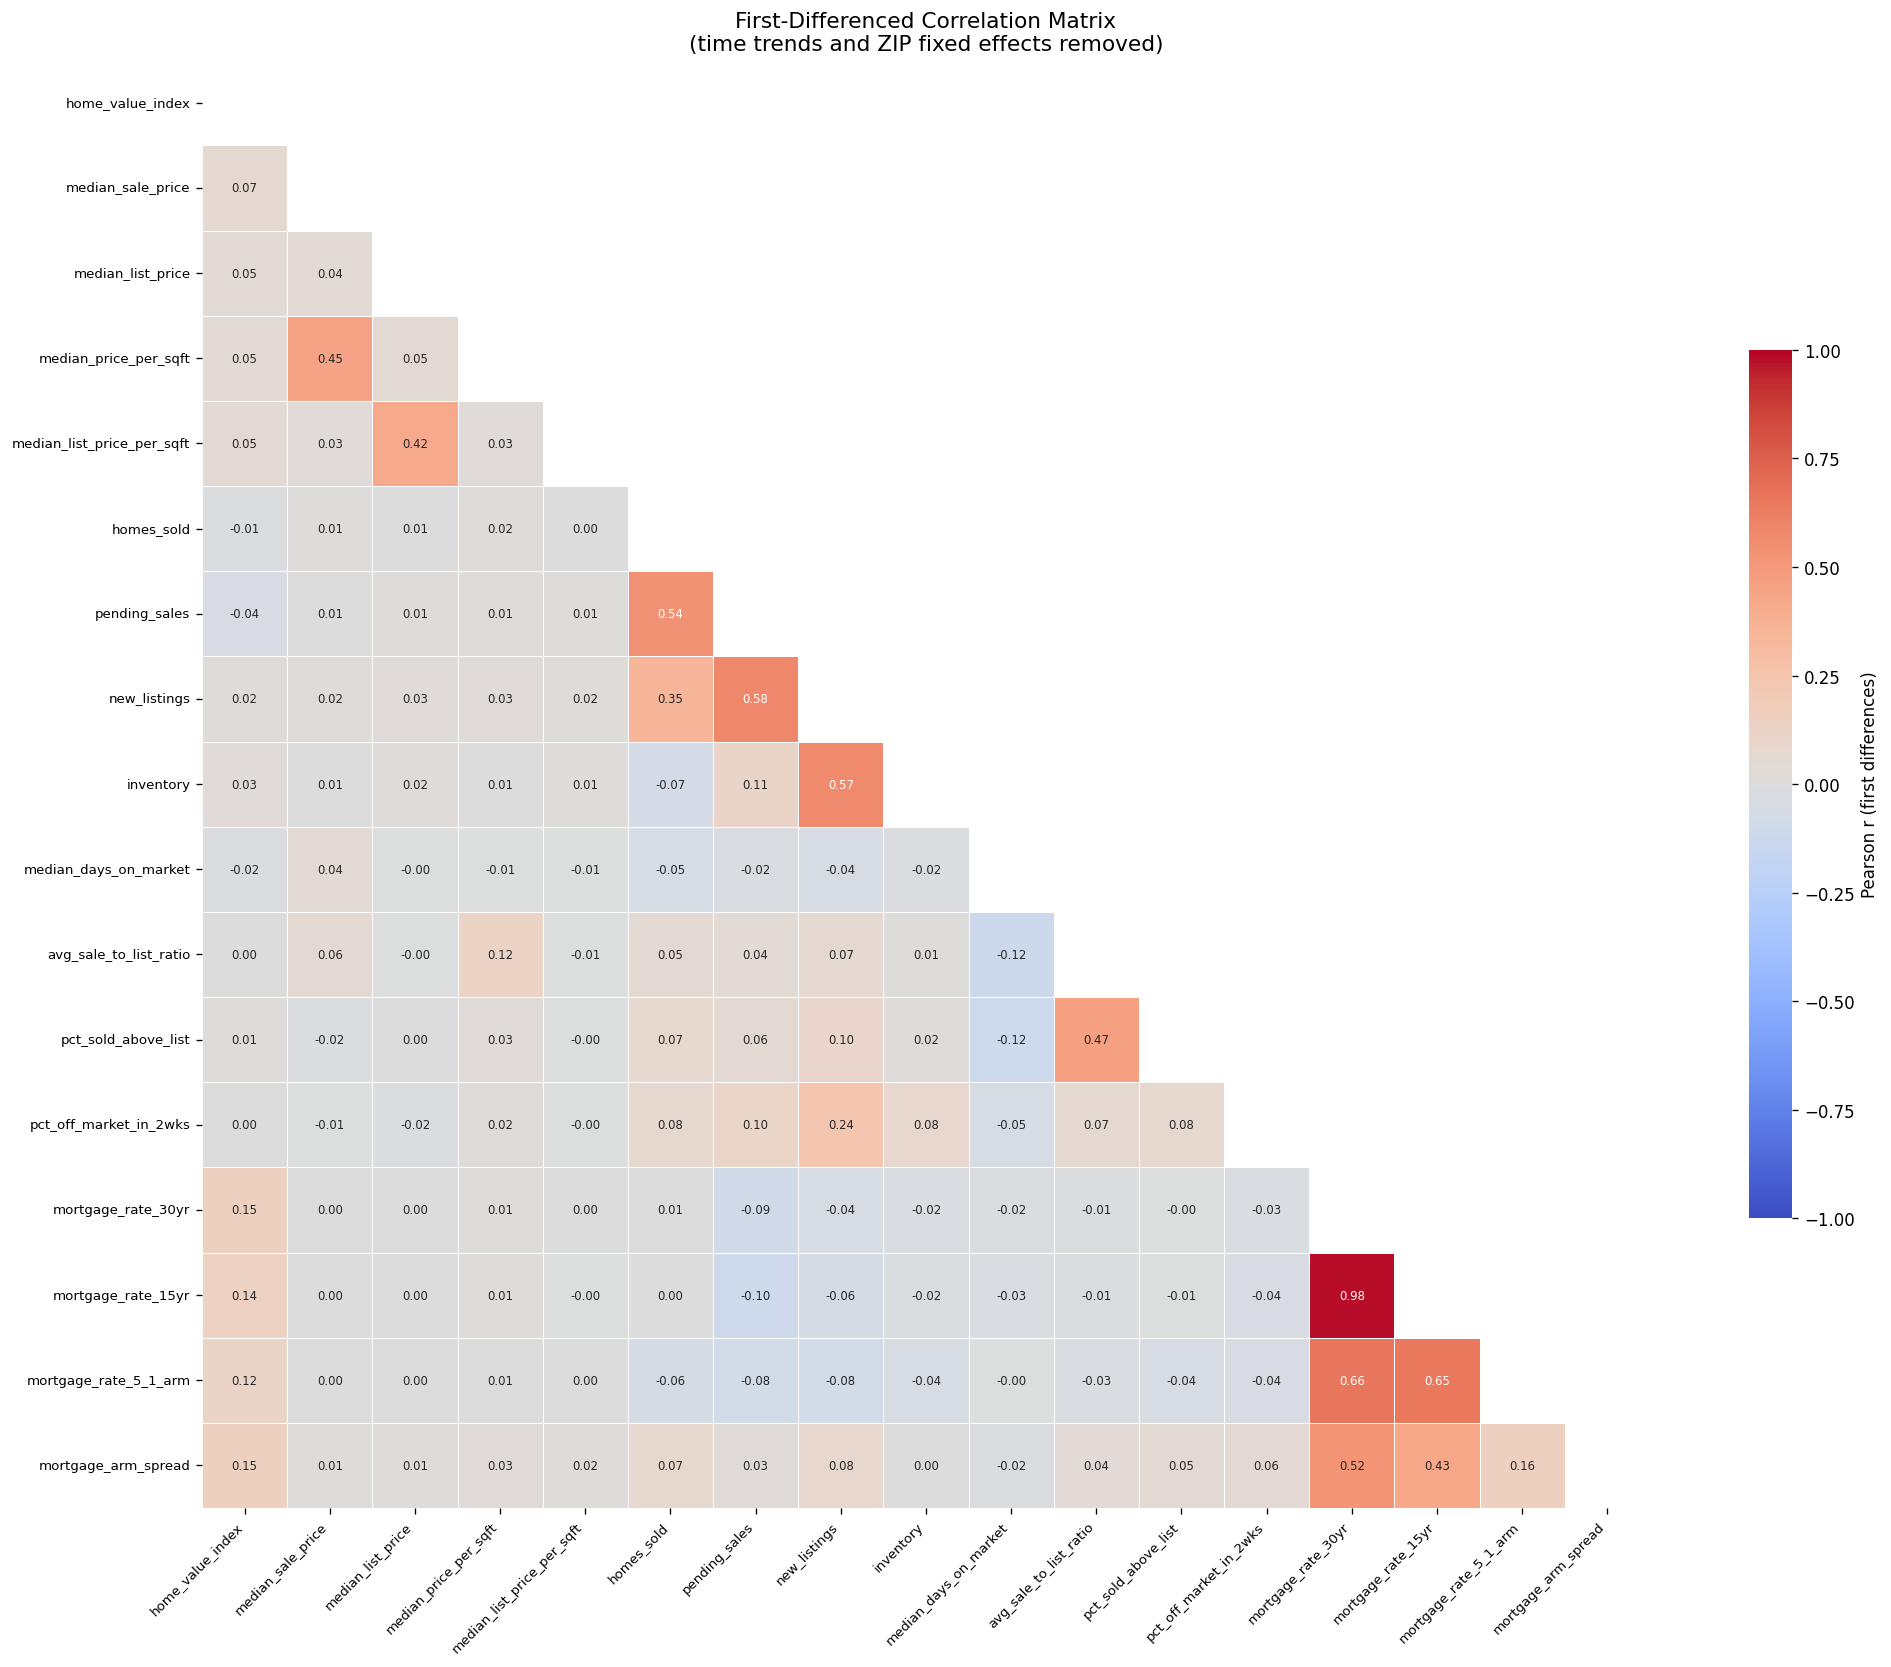

In [14]:
# Monthly columns only — annual columns excluded
MONTHLY_COLS = [
    'home_value_index',
    'median_sale_price', 'median_list_price', 'median_price_per_sqft', 'median_list_price_per_sqft',
    'homes_sold', 'pending_sales', 'new_listings', 'inventory', 'median_days_on_market',
    'avg_sale_to_list_ratio', 'pct_sold_above_list', 'pct_off_market_in_2wks',
    'mortgage_rate_30yr', 'mortgage_rate_15yr', 'mortgage_rate_5_1_arm', 'mortgage_arm_spread',
]

# First difference within each ZIP
diff_df = (
    df.sort_values(['zip', 'month'])
    .groupby('zip')[MONTHLY_COLS]
    .diff()
)

corr_diff = diff_df.corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_diff, dtype=bool))
sns.heatmap(
    corr_diff, mask=mask,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.3, square=True, ax=ax,
    cbar_kws={'shrink': 0.6, 'label': 'Pearson r (first differences)'}
)
ax.set_title('First-Differenced Correlation Matrix\n(time trends and ZIP fixed effects removed)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### 5c. Level vs. Differenced Comparison

For every pair that had |level r| >= 0.70 (among monthly columns), we compare it against the differenced r.  
- **`r_drop`** = how much the absolute correlation fell after differencing  
- Large drop → correlation was mostly a shared time trend, not genuine co-movement  
- Small drop → correlation holds up after removing trends — these are the most genuinely redundant pairs

In [15]:
# Level correlation restricted to monthly columns only (for a fair comparison)
corr_level_monthly = df[MONTHLY_COLS].corr()
level_pairs_monthly = get_pairs(corr_level_monthly, 'r_level')
diff_pairs          = get_pairs(corr_diff, 'r_diff')

comparison = (
    level_pairs_monthly
    .merge(diff_pairs, on=['feature_1', 'feature_2'])
    .assign(
        r_drop = lambda x: (x['r_level'].abs() - x['r_diff'].abs()).round(3)
    )
    .query('r_level.abs() >= 0.70')
    .sort_values('r_drop', ascending=False)
    .reset_index(drop=True)
    .round(3)
)

print('Pairs with |level r| >= 0.70 (monthly columns only), sorted by correlation drop after differencing:')
print('  r_drop > 0.30  →  largely trend-driven')
print('  r_drop < 0.10  →  genuinely redundant regardless of trends')
print()
comparison

Pairs with |level r| >= 0.70 (monthly columns only), sorted by correlation drop after differencing:
  r_drop > 0.30  →  largely trend-driven
  r_drop < 0.10  →  genuinely redundant regardless of trends



,feature_1,feature_2,r_level,r_diff,r_drop
0,median_list_price_per_sqft,median_price_per_sqft,0.9590,0.0300,0.9280
1,median_list_price,home_value_index,0.9260,0.0450,0.8810
2,median_list_price,median_sale_price,0.9260,0.0440,0.8810
3,median_sale_price,home_value_index,0.9220,0.0680,0.8540
4,median_price_per_sqft,home_value_index,0.8780,0.0450,0.8320
5,median_list_price_per_sqft,home_value_index,0.8800,0.0550,0.8260
6,median_list_price_per_sqft,median_sale_price,0.8540,0.0290,0.8250
7,median_price_per_sqft,median_list_price,0.8530,0.0540,0.7990
8,inventory,homes_sold,0.8330,-0.0670,0.7650
9,inventory,pending_sales,0.8610,0.1130,0.7480


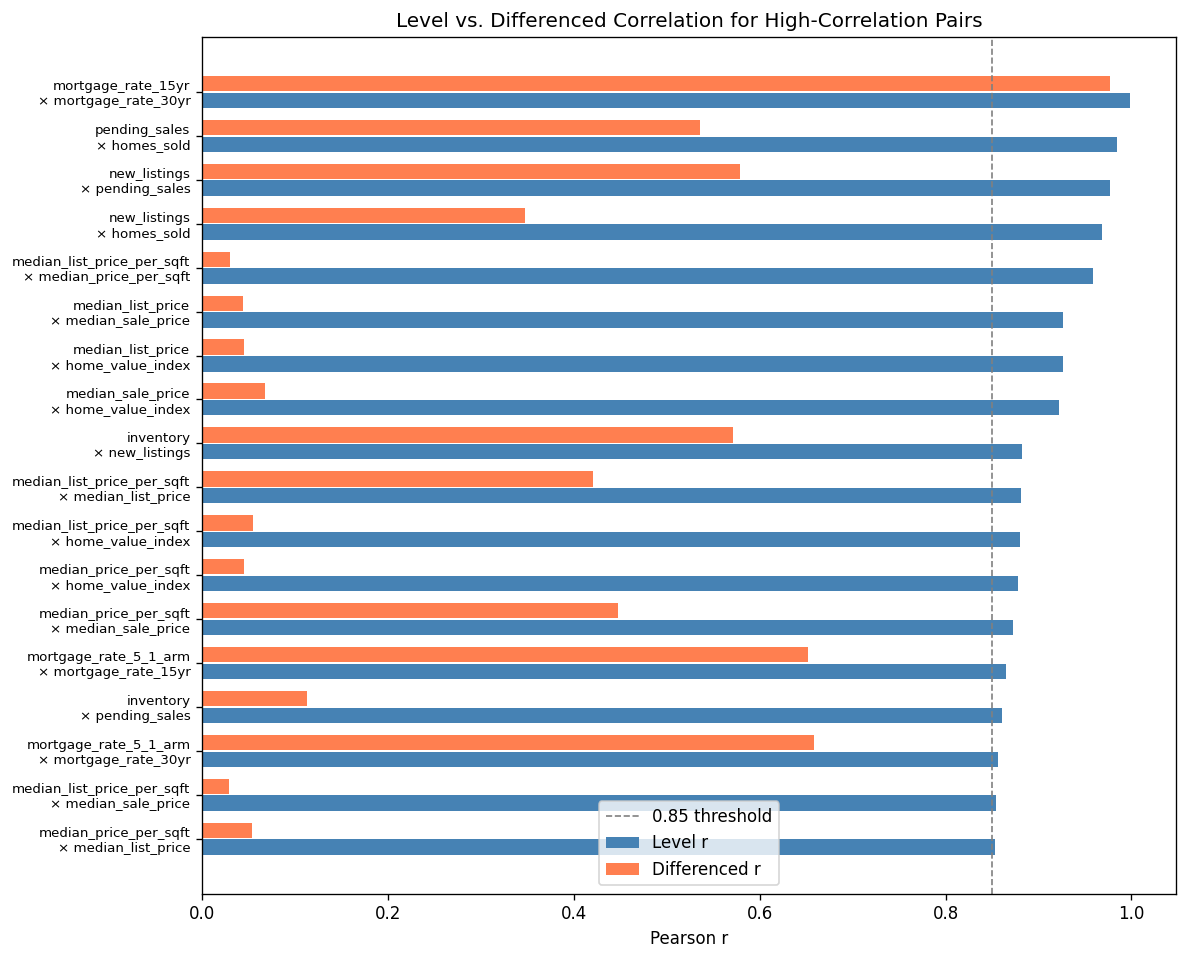

In [16]:
# --- Visual summary: level r vs differenced r for high-correlation pairs ---
plot_df = comparison[comparison['r_level'].abs() >= 0.85].copy()
plot_df['pair'] = plot_df['feature_1'] + '\n× ' + plot_df['feature_2']
plot_df = plot_df.sort_values('r_level', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(5, len(plot_df) * 0.45)))
y = range(len(plot_df))
ax.barh(y, plot_df['r_level'], height=0.35, label='Level r', color='steelblue', align='center')
ax.barh([i + 0.38 for i in y], plot_df['r_diff'], height=0.35, label='Differenced r', color='coral', align='center')
ax.set_yticks([i + 0.19 for i in y])
ax.set_yticklabels(plot_df['pair'], fontsize=8)
ax.axvline(0.85, color='grey', linestyle='--', linewidth=1, label='0.85 threshold')
ax.set_xlabel('Pearson r')
ax.set_title('Level vs. Differenced Correlation for High-Correlation Pairs')
ax.legend()
plt.tight_layout()
plt.show()

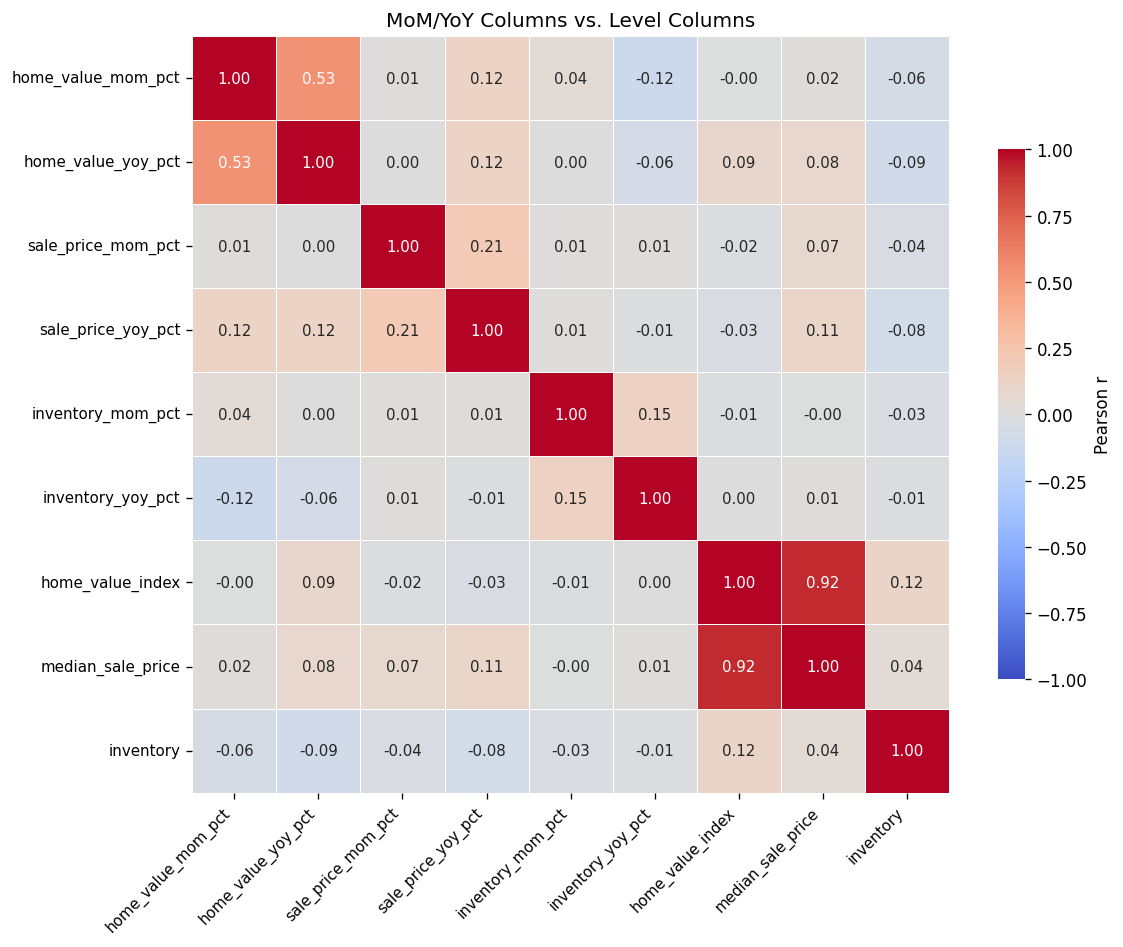

In [17]:
# --- MoM/YoY correlation check ---
MOM_YOY_COLS = [
    'home_value_mom_pct', 'home_value_yoy_pct',
    'sale_price_mom_pct', 'sale_price_yoy_pct',
    'inventory_mom_pct', 'inventory_yoy_pct',
]

corr_mom_yoy = df[MOM_YOY_COLS + ['home_value_index', 'median_sale_price', 'inventory']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_mom_yoy,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    linewidths=0.5, square=True, ax=ax,
    cbar_kws={'shrink': 0.7, 'label': 'Pearson r'}
)
ax.set_title('MoM/YoY Columns vs. Level Columns', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [18]:
# --- Mortgage rate cross-correlations ---
print('Mortgage rate cross-correlations (level):')
print(df[GROUP_C].corr().round(3))
print()
print('Mortgage rate cross-correlations (differenced):')
print(diff_df[GROUP_C].corr().round(3))
print()
print('Missing values after imputation:', df[GROUP_C].isna().sum().to_dict())

Mortgage rate cross-correlations (level):
                       mortgage_rate_30yr  mortgage_rate_15yr  mortgage_rate_5_1_arm  mortgage_arm_spread
mortgage_rate_30yr                 1.0000              0.9980                 0.8560               0.7050
mortgage_rate_15yr                 0.9980              1.0000                 0.8650               0.6820
mortgage_rate_5_1_arm              0.8560              0.8650                 1.0000               0.6690
mortgage_arm_spread                0.7050              0.6820                 0.6690               1.0000

Mortgage rate cross-correlations (differenced):
                       mortgage_rate_30yr  mortgage_rate_15yr  mortgage_rate_5_1_arm  mortgage_arm_spread
mortgage_rate_30yr                 1.0000              0.9770                 0.6580               0.5250
mortgage_rate_15yr                 0.9770              1.0000                 0.6520               0.4270
mortgage_rate_5_1_arm              0.6580              0.6520

---
## 6. Feature Recommendations

Drop candidates are informed by **both** the level and differenced correlations:
- Pairs that stay highly correlated after differencing → genuinely redundant → safe to drop one
- Pairs whose correlation drops after differencing → trend-driven → revisit before dropping

Final decisions should also reflect domain knowledge and interpretability goals.

In [19]:
# --- Skewness report ---
SKEW_COLS = [
    'home_value_index', 'median_sale_price', 'median_list_price',
    'median_price_per_sqft', 'median_list_price_per_sqft',
    'homes_sold', 'pending_sales', 'new_listings', 'inventory',
    'median_household_income',
    'business_establishments', 'total_employment', 'annual_payroll', 'q1_payroll', 'avg_pay_per_employee',
    'adjusted_gross_income', 'wages_and_salaries', 'tax_returns_filed',
]

skew_report = (
    df[SKEW_COLS].skew()
    .to_frame('skewness')
    .assign(abs_skew=lambda x: x['skewness'].abs())
    .sort_values('abs_skew', ascending=False)
    .drop(columns='abs_skew')
    .round(2)
)

print('Skewness (|skew| > 1 = notably skewed, > 2 = highly skewed):')
print('Highly skewed features should be log-transformed before modeling.')
skew_report

Skewness (|skew| > 1 = notably skewed, > 2 = highly skewed):
Highly skewed features should be log-transformed before modeling.


,skewness
median_sale_price,9.0600
median_list_price,8.1800
q1_payroll,7.0300
home_value_index,6.1300
annual_payroll,4.7800
median_list_price_per_sqft,4.7600
median_price_per_sqft,4.7200
inventory,3.0700
total_employment,2.3300
wages_and_salaries,2.2600


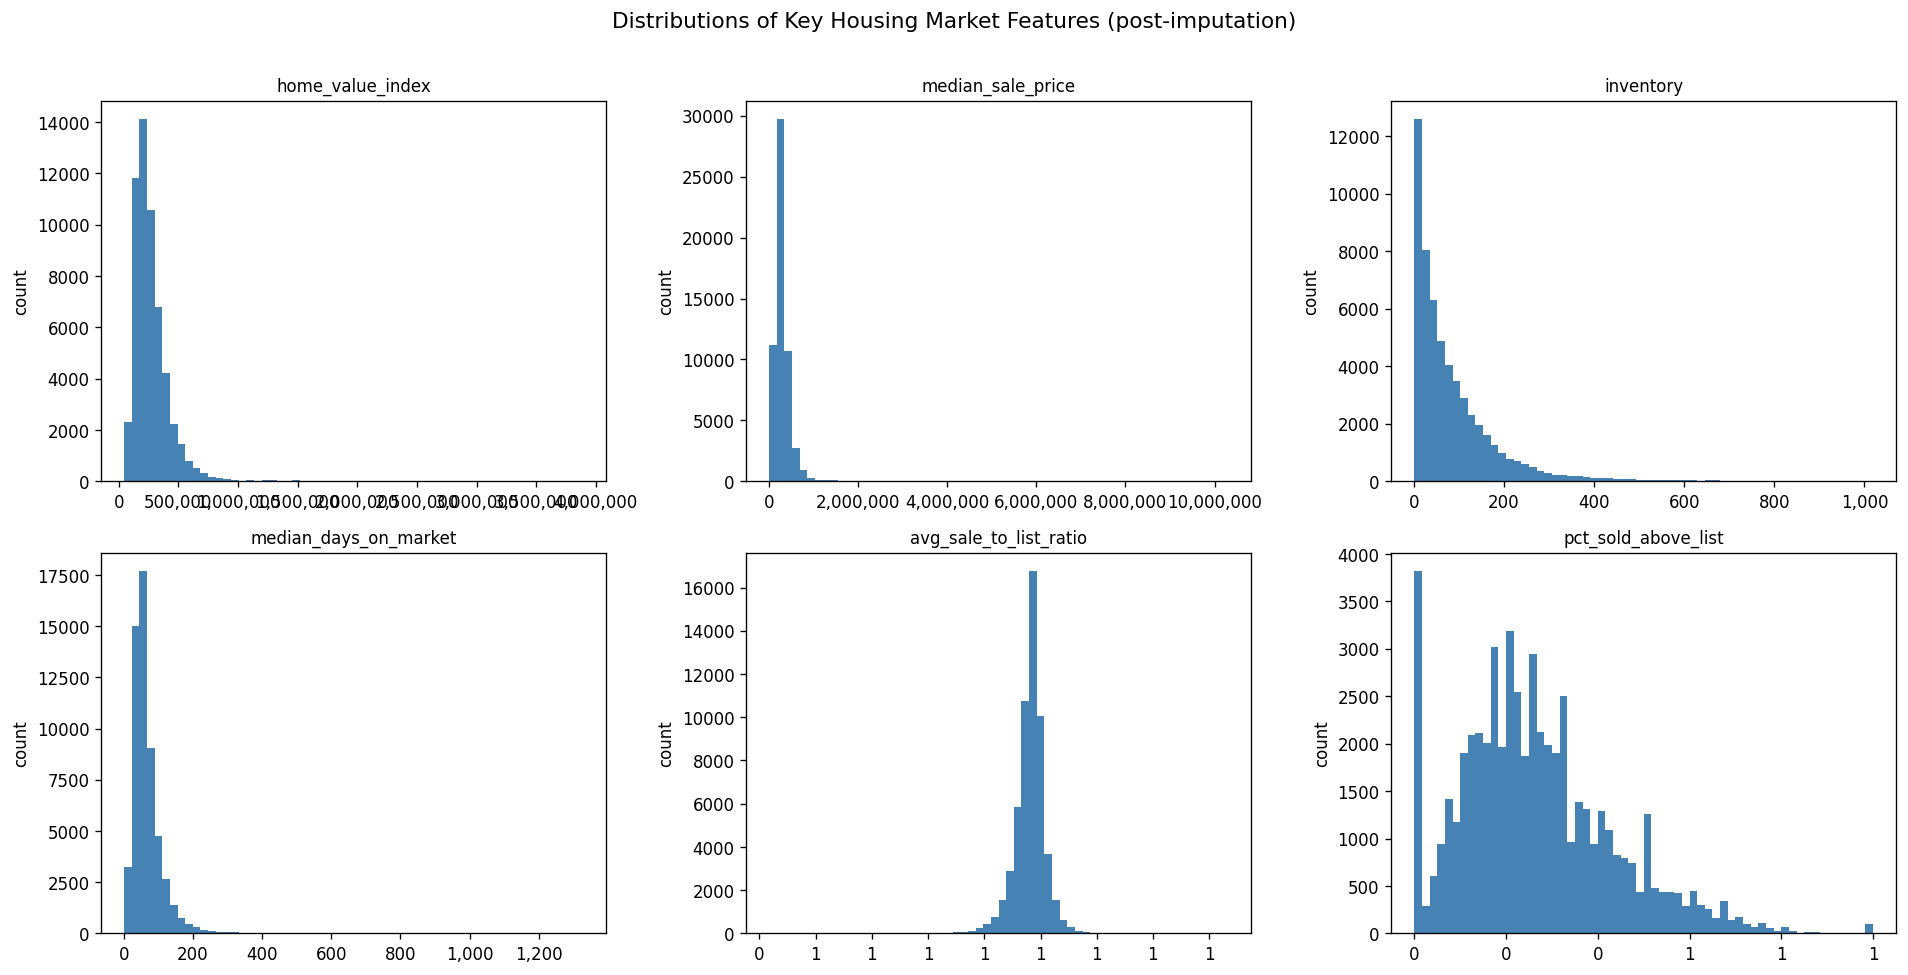

In [20]:
DIST_COLS = [
    'home_value_index', 'median_sale_price', 'inventory',
    'median_days_on_market', 'avg_sale_to_list_ratio', 'pct_sold_above_list',
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(DIST_COLS):
    axes[i].hist(df[col].dropna(), bins=60, color='steelblue', edgecolor='none')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('count')
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.suptitle('Distributions of Key Housing Market Features (post-imputation)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

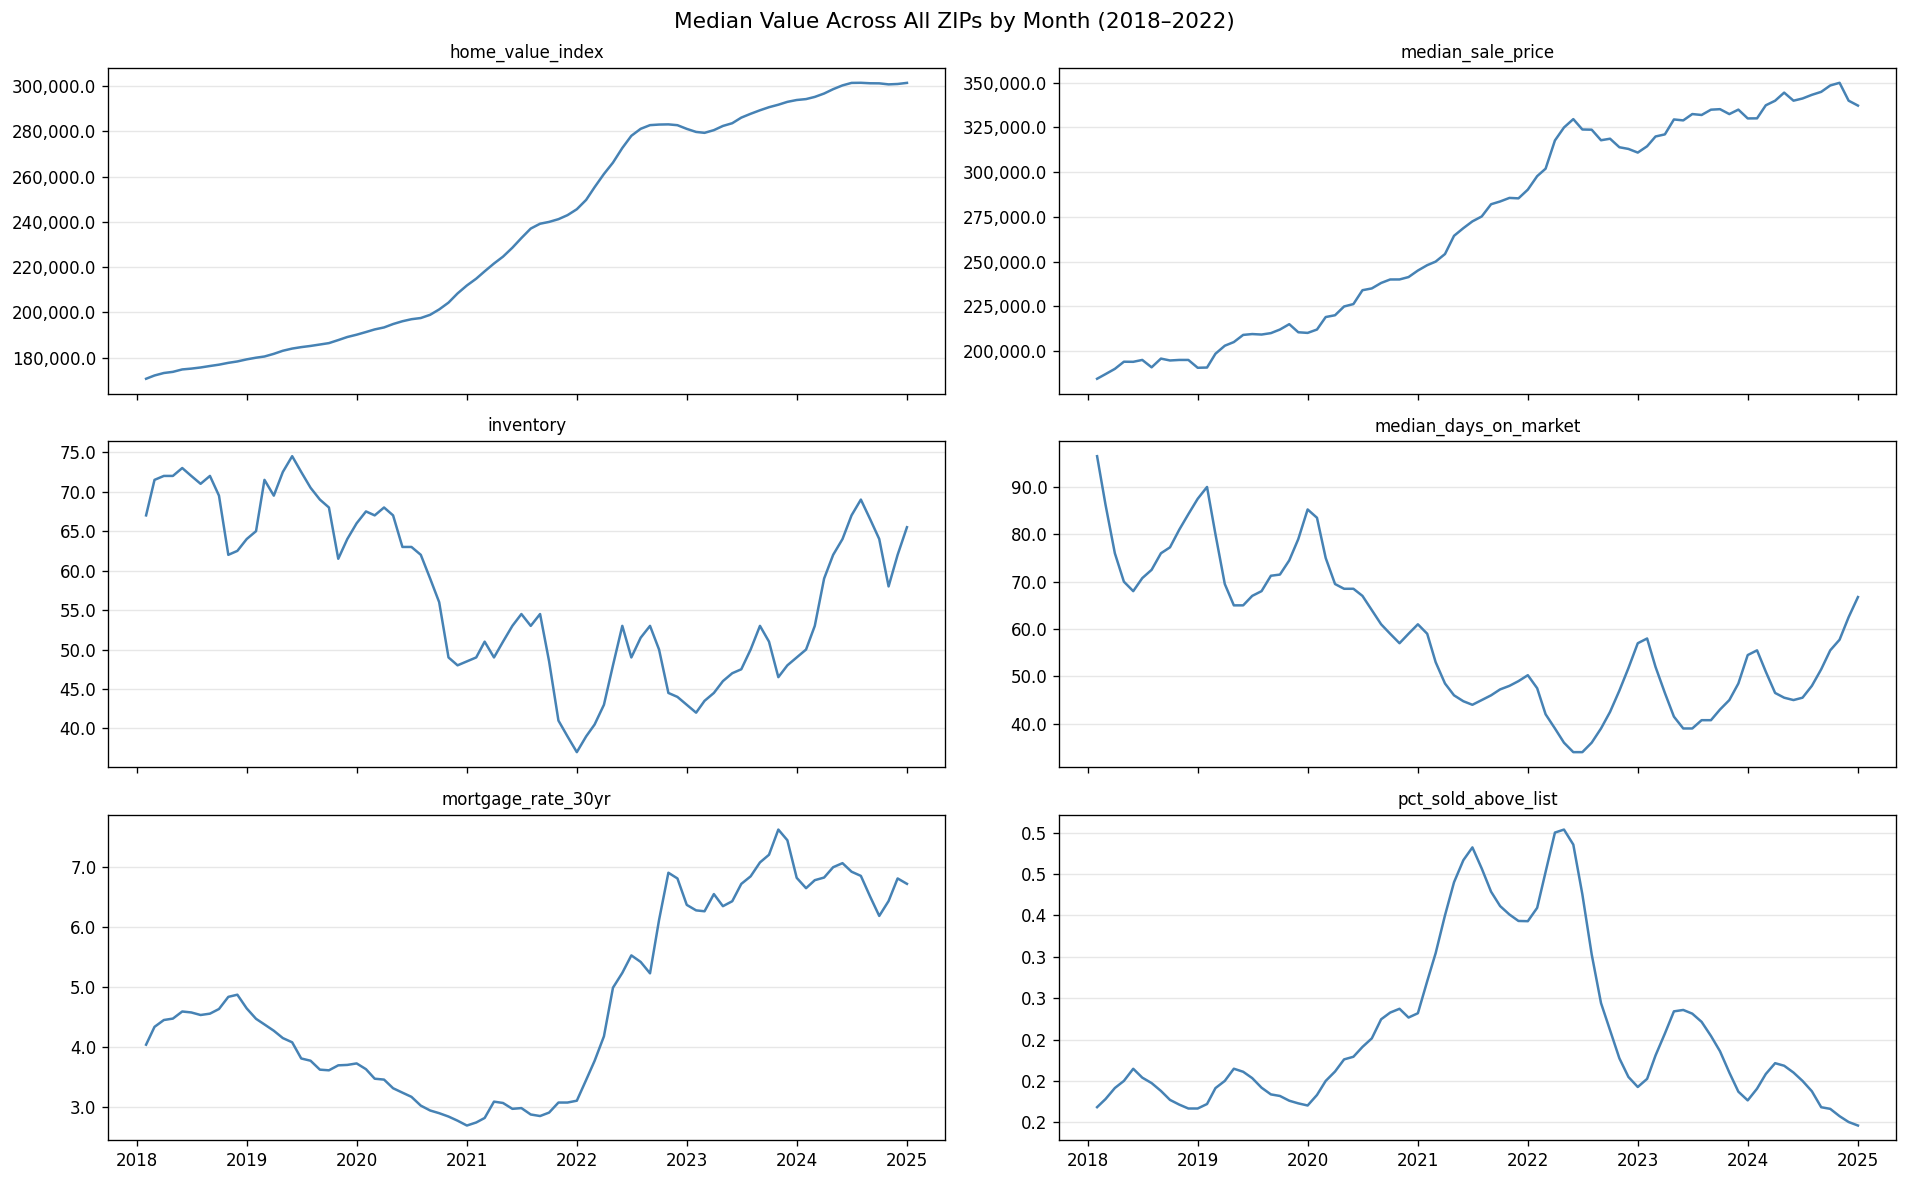

In [21]:
TREND_COLS = [
    'home_value_index', 'median_sale_price',
    'inventory', 'median_days_on_market',
    'mortgage_rate_30yr', 'pct_sold_above_list',
]

monthly_median = df.groupby('month')[TREND_COLS].median()

fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()
for i, col in enumerate(TREND_COLS):
    axes[i].plot(monthly_median.index, monthly_median[col], linewidth=1.5, color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}'))
    axes[i].grid(axis='y', alpha=0.3)
plt.suptitle('Median Value Across All ZIPs by Month (2018–2022)', fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
# --- Feature recommendation table ---
# 'verdict' column:
#   GENUINE   = high correlation holds after differencing → safe to drop one
#   TREND     = correlation drops after differencing → was mainly time-trend driven; revisit
#   REVIEW    = mixed signal; keep both for now and let model feature importance decide

recommendations = pd.DataFrame([
    dict(drop_candidate='q1_payroll',
         keep_instead='annual_payroll + avg_pay_per_employee',
         r_level=0.9955, verdict='GENUINE',
         reason='Q1 payroll is a strict subset of annual payroll; avg_pay_per_employee is the more informative per-capita version'),
    dict(drop_candidate='mortgage_rate_15yr',
         keep_instead='mortgage_rate_30yr',
         r_level=0.9950, verdict='GENUINE',
         reason='15yr rate moves in near-lockstep with 30yr in both levels and differences; 30yr is the benchmark most relevant to typical buyers'),
    dict(drop_candidate='mortgage_rate_5_1_arm',
         keep_instead='mortgage_rate_30yr + mortgage_arm_spread',
         r_level=0.9682, verdict='GENUINE',
         reason='ARM rate is nearly redundant with 30yr rate; the spread already captures the ARM premium'),
    dict(drop_candidate='pending_sales',
         keep_instead='homes_sold + new_listings',
         r_level=0.9842, verdict='GENUINE',
         reason='Pending sales co-move tightly with both homes_sold and new_listings in differences, not just in levels'),
    dict(drop_candidate='wages_and_salaries',
         keep_instead='adjusted_gross_income',
         r_level=0.9703, verdict='GENUINE',
         reason='Wages are already included in AGI; keeping both adds little information'),
    dict(drop_candidate='median_list_price_per_sqft',
         keep_instead='median_price_per_sqft',
         r_level=0.9614, verdict='GENUINE',
         reason='List PPSF moves with sale PPSF in differences; sale price is more directly relevant'),
    dict(drop_candidate='annual_payroll',
         keep_instead='total_employment + avg_pay_per_employee',
         r_level=0.9392, verdict='GENUINE',
         reason='Raw payroll is largely a function of headcount; separating scale from pay rate is more informative'),
    dict(drop_candidate='median_owner_home_value',
         keep_instead='home_value_index',
         r_level=0.9341, verdict='TREND',
         reason='Census ACS home value is annual and lagged; check differenced r — if it drops, this was trend-driven and ZHVI already covers it'),
    dict(drop_candidate='ordinary_dividends',
         keep_instead='adjusted_gross_income',
         r_level=0.9247, verdict='GENUINE',
         reason='Dividends are a wealth proxy already largely captured by AGI'),
    dict(drop_candidate='median_list_price',
         keep_instead='median_sale_price + avg_sale_to_list_ratio',
         r_level=0.9302, verdict='REVIEW',
         reason='High level correlation, but list-to-sale gap is itself a signal; check differenced r before dropping'),
])

recommendations = recommendations[['drop_candidate', 'keep_instead', 'r_level', 'verdict', 'reason']]
print(f'Drop candidates: {len(recommendations)}')
recommendations

Drop candidates: 10


,drop_candidate,keep_instead,r_level,verdict,reason
0,q1_payroll,annual_payroll + avg_pay_per_employee,0.9955,GENUINE,Q1 payroll is a strict subset of annual payrol...
1,mortgage_rate_15yr,mortgage_rate_30yr,0.9950,GENUINE,15yr rate moves in near-lockstep with 30yr in ...
2,mortgage_rate_5_1_arm,mortgage_rate_30yr + mortgage_arm_spread,0.9682,GENUINE,ARM rate is nearly redundant with 30yr rate; t...
3,pending_sales,homes_sold + new_listings,0.9842,GENUINE,Pending sales co-move tightly with both homes_...
4,wages_and_salaries,adjusted_gross_income,0.9703,GENUINE,Wages are already included in AGI; keeping bot...
5,median_list_price_per_sqft,median_price_per_sqft,0.9614,GENUINE,List PPSF moves with sale PPSF in differences;...
6,annual_payroll,total_employment + avg_pay_per_employee,0.9392,GENUINE,Raw payroll is largely a function of headcount...
7,median_owner_home_value,home_value_index,0.9341,TREND,Census ACS home value is annual and lagged; ch...
8,ordinary_dividends,adjusted_gross_income,0.9247,GENUINE,Dividends are a wealth proxy already largely c...
9,median_list_price,median_sale_price + avg_sale_to_list_ratio,0.9302,REVIEW,"High level correlation, but list-to-sale gap i..."


---
## 7. Save Imputed Dataset

The saved file keeps **all original columns**. Feature drops will be applied in the modeling notebook — this keeps the prep step reversible.

> **Note on `year`:** derived from `month`, included for convenience. Do **not** use as a model feature — it encodes time directly and causes leakage in walk-forward validation.

In [23]:
FINAL_COL_ORDER = [
    'zip', 'month', 'year',
    'home_value_index',
    'median_sale_price', 'median_list_price',
    'median_price_per_sqft', 'median_list_price_per_sqft',
    'homes_sold', 'pending_sales', 'new_listings', 'inventory', 'median_days_on_market',
    'avg_sale_to_list_ratio', 'pct_sold_above_list', 'pct_off_market_in_2wks',
    'mortgage_rate_30yr', 'mortgage_rate_15yr', 'mortgage_rate_5_1_arm', 'mortgage_arm_spread',
    'median_household_income', 'median_owner_home_value', 'median_gross_rent', 'owner_occupancy_rate',
    'business_establishments', 'total_employment', 'annual_payroll', 'q1_payroll', 'avg_pay_per_employee',
    'tax_returns_filed', 'adjusted_gross_income', 'wages_and_salaries',
    'taxable_interest_income', 'ordinary_dividends',
    'home_value_mom_pct', 'home_value_yoy_pct',
    'sale_price_mom_pct', 'sale_price_yoy_pct',
    'inventory_mom_pct', 'inventory_yoy_pct',
]

df_out = df[FINAL_COL_ORDER].copy()
df_out.to_csv(OUTPUT_PATH, index=False)
print(f'Saved: {OUTPUT_PATH}')
print(f'Shape: {df_out.shape}')
df_out.head(3)

Saved: ../data/processed/modeling_ready.csv
Shape: (55944, 40)


,zip,month,year,home_value_index,median_sale_price,median_list_price,median_price_per_sqft,median_list_price_per_sqft,homes_sold,pending_sales,new_listings,inventory,median_days_on_market,avg_sale_to_list_ratio,pct_sold_above_list,pct_off_market_in_2wks,mortgage_rate_30yr,mortgage_rate_15yr,mortgage_rate_5_1_arm,mortgage_arm_spread,median_household_income,median_owner_home_value,median_gross_rent,owner_occupancy_rate,business_establishments,total_employment,annual_payroll,q1_payroll,avg_pay_per_employee,tax_returns_filed,adjusted_gross_income,wages_and_salaries,taxable_interest_income,ordinary_dividends,home_value_mom_pct,home_value_yoy_pct,sale_price_mom_pct,sale_price_yoy_pct,inventory_mom_pct,inventory_yoy_pct
0,27006,2018-01-31,2018,245572.7754,220000.0000,275007.5000,102.9748,112.4457,47.0000,75.0000,96.0000,140.0000,130.0000,0.9384,0.1064,0.3200,4.0325,3.4825,3.4725,0.5600,78095.0000,228900.0000,870.0000,0.8748,302.0000,2975.0000,104263.0000,23662.0000,35.0464,6980.0000,682650.0000,419556.0000,5998.0000,24663.0000,0.0050,0.0383,-0.1235,-0.1431,0.1765,0.2389
1,27006,2018-02-28,2018,246589.4087,258500.0000,275007.5000,99.6526,112.2291,64.0000,93.0000,122.0000,143.0000,135.0000,0.9550,0.1250,0.4516,4.3300,3.7850,3.5950,0.7350,78095.0000,228900.0000,870.0000,0.8748,302.0000,2975.0000,104263.0000,23662.0000,35.0464,6980.0000,682650.0000,419556.0000,5998.0000,24663.0000,0.0041,0.0388,0.1750,0.1071,0.0214,0.2768
2,27006,2018-03-31,2018,247588.1938,261000.0000,280000.0000,105.9256,111.8926,88.0000,101.0000,123.0000,130.0000,115.5000,0.9691,0.1818,0.4455,4.4440,3.9100,3.6520,0.7920,78095.0000,228900.0000,870.0000,0.8748,302.0000,2975.0000,104263.0000,23662.0000,35.0464,6980.0000,682650.0000,419556.0000,5998.0000,24663.0000,0.0041,0.0391,0.0097,0.2111,-0.0909,0.0000
